In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def load_data(filename):
    data = np.loadtxt(filename, delimiter=",")
    X = data[:, :2]
    y = data[:, 2]
    return X, y

In [7]:
X_train, y_train = load_data("projects/basic/ex2data1.txt")

In [8]:
print(X_train[:5])
print(y_train[:5])

[[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
[0. 0. 0. 1. 1.]


In [9]:
print(X_train.shape)
print(y_train.shape)

(100, 2)
(100,)


In [10]:
def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = y == 1
    negative = y == 0
    
    # Plot examples
    plt.plot(X[positive, 0], X[positive, 1], "k+", label=pos_label)
    plt.plot(X[negative, 0], X[negative, 1], "yo", label=neg_label)

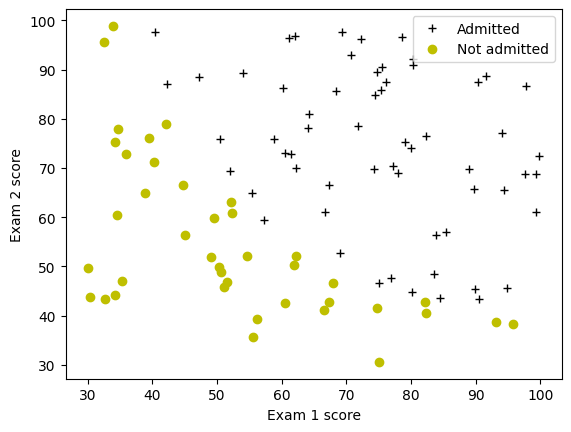

In [11]:
plot_data(X_train, y_train[:], pos_label="Admitted", neg_label="Not admitted")

plt.ylabel("Exam 2 score")
plt.xlabel("Exam 1 score")
plt.legend(loc="upper right")
plt.show()

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [13]:
print(sigmoid(0))
print(sigmoid(np.array([1,2,3,4])))

0.5
[0.73105858 0.88079708 0.95257413 0.98201379]


In [14]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    total_loss = 0
    for i in range(m):
        f_w_b = sigmoid(np.dot(X[i], w) + b)
        total_loss += -y[i] * (np.log(f_w_b)) - (1-y[i]) * (np.log(1-f_w_b))
    
    return total_loss / m

In [15]:
m, n = X_train.shape
init_w = np.zeros(n)
init_b = 0.
cost = compute_cost(X_train, y_train, init_w, init_b)
print(f"Initial cost: {cost:.3f}")

Initial cost: 0.693


In [16]:
def compute_gradient(X, y, w, b):
    m, n = np.shape(X)
    dj_dw = np.zeros(n)
    dj_db = 0.

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i][j]
        dj_db += err

    dj_dw /= m
    dj_db /=m
    return dj_dw, dj_db
        

In [17]:
init_w = np.zeros(n)
init_b = 0.

dj_dw, dj_db = compute_gradient(X_train, y_train, init_w, init_b)
print(dj_dw, dj_db)

[-12.00921659 -11.26284221] -0.1


In [18]:
import copy

def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w = copy.deepcopy(w_init)
    b = b_init

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        
        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i % 1000 == 0:
            cost = compute_cost(X, y, w, b)
            print(f"Iteration: {i:4d}, Cost: {cost:8.2f}")
    return w, b

In [37]:
# np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2).reshape(-1,1) - 0.5)
# initial_w = np.random.rand(2)
init_b = -5

iterations = 100000
alpha = 0.001
w, b = gradient_descent(X_train, y_train, init_w, init_b, alpha, iterations)
print("Weights after descent: ", w)
print("Bias after descent: ", b)

/tmp/ipykernel_9239/1501431978.py:7: RuntimeWarning: divide by zero encountered in log
  total_loss += -y[i] * (np.log(f_w_b)) - (1-y[i]) * (np.log(1-f_w_b))
/tmp/ipykernel_9239/1501431978.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  total_loss += -y[i] * (np.log(f_w_b)) - (1-y[i]) * (np.log(1-f_w_b))


Iteration:    0, Cost:      nan
Iteration: 1000, Cost:     0.38
Iteration: 2000, Cost:     0.38
Iteration: 3000, Cost:     0.38
Iteration: 4000, Cost:     0.38
Iteration: 5000, Cost:     0.38
Iteration: 6000, Cost:     0.37
Iteration: 7000, Cost:     0.37
Iteration: 8000, Cost:     0.37
Iteration: 9000, Cost:     0.37
Iteration: 10000, Cost:     0.37
Iteration: 11000, Cost:     0.37
Iteration: 12000, Cost:     0.37
Iteration: 13000, Cost:     0.37
Iteration: 14000, Cost:     0.37
Iteration: 15000, Cost:     0.37
Iteration: 16000, Cost:     0.37
Iteration: 17000, Cost:     0.36
Iteration: 18000, Cost:     0.36
Iteration: 19000, Cost:     0.36
Iteration: 20000, Cost:     0.36
Iteration: 21000, Cost:     0.36
Iteration: 22000, Cost:     0.36
Iteration: 23000, Cost:     0.36
Iteration: 24000, Cost:     0.36
Iteration: 25000, Cost:     0.36
Iteration: 26000, Cost:     0.36
Iteration: 27000, Cost:     0.36
Iteration: 28000, Cost:     0.36
Iteration: 29000, Cost:     0.35
Iteration: 30000, Co

In [20]:
init_w

array([0.06639059, 0.50015353])

In [21]:
def plot_decision_boundary(w, b, X, y):
    # Credit to dibgerge on Github for this plotting code
     
    plot_data(X[:, 0:2], y)
    
    if X.shape[1] <= 2:
        plot_x = np.array([min(X[:, 0]), max(X[:, 0])])
        plot_y = (-1. / w[1]) * (w[0] * plot_x + b)
        
        plt.plot(plot_x, plot_y, c="b")
        
    else:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)
        
        z = np.zeros((len(u), len(v)))

        # Evaluate z = theta*x over the grid
        for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = sig(np.dot(map_feature(u[i], v[j]), w) + b)
        
        # important to transpose z before calling contour       
        z = z.T
        
        # Plot z = 0
        plt.contour(u,v,z, levels = [0.5], colors="g")

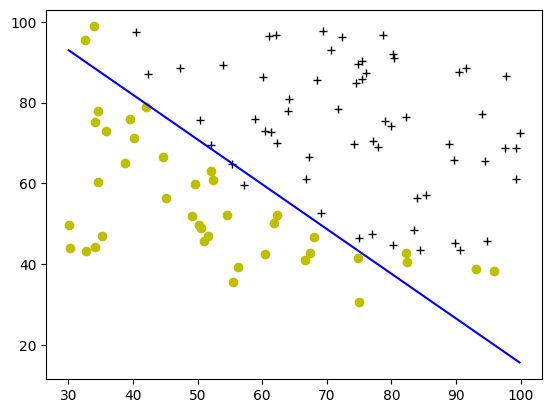

In [38]:
plot_decision_boundary(w, b, X_train, y_train)